# 05 — Logistic Regression

Este notebook entrena la versión seria de Logistic Regression sobre el conjunto seleccionado en Feature Engineering. `LeadTime` se reemplaza por bandas operativas y se agrega `HasSpecialRequests`; el resto parte del primer lote parsimonioso.

La selección de hiperparámetros utiliza exclusivamente 2015–2016 mediante cinco folds estratificados y agrupados. El holdout temporal de 2017 se consulta una sola vez después de cerrar la búsqueda. ROC AUC es la métrica principal y el threshold se mantiene en 0,5 únicamente para comparar métricas basadas en clases.

## Imports y resolución de la raíz

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)

In [2]:
def find_project_root(start_path=None):
    """Busca la raíz del repositorio a partir del directorio actual."""
    start = Path(start_path or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").is_dir() and (candidate / "src").is_dir():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    raise FileNotFoundError("No se encontró la raíz local del proyecto.")

project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: C:\Code\Vialesoft\Vialesoft_Devlab\Mini_Proyectos\Machine_Learning\Obligatorio2026


In [3]:
from src.config import RANDOM_STATE, RAW_DATA_DIR
from src.data import (
    combine_hotel_datasets,
    load_csv_with_fallback,
    make_temporal_holdout_split,
    normalize_text_values,
)
from src.evaluation import (
    evaluate_binary_classifier,
    get_grid_results,
    get_stratified_group_cross_validation,
    run_grid_search,
)
from src.features import (
    build_base_feature_set,
    build_logistic_second_batch_candidate_set,
    get_feature_types,
    make_exact_feature_groups,
)
from src.plots import plot_confusion_matrix
from src.preprocessing import build_tabular_preprocessor

## Carga e integración de los datos

In [4]:
H1_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H1.csv"
H2_URL = "https://raw.githubusercontent.com/Lithium582/Obligatorio2026/refs/heads/main/data/raw/H2.csv"

h1_df = load_csv_with_fallback(RAW_DATA_DIR / "H1.csv", H1_URL)
h2_df = load_csv_with_fallback(RAW_DATA_DIR / "H2.csv", H2_URL)
bookings_df = combine_hotel_datasets(h1_df, h2_df)
bookings_df = normalize_text_values(bookings_df)

print(f"Dataset integrado: {bookings_df.shape[0]:,} filas y {bookings_df.shape[1]} columnas.")

Dataset integrado: 119,390 filas y 32 columnas.


## Conjunto seleccionado para Logistic Regression

El constructor reproduce todas las decisiones de los dos lotes de Feature Engineering. Se valida explícitamente que `LeadTime` haya sido reemplazado y que las dos variables seleccionadas estén presentes.

In [5]:
X_reference, y = build_base_feature_set(bookings_df)
X = build_logistic_second_batch_candidate_set(X_reference)
numeric_features, categorical_features = get_feature_types(
    X, require_all_categorical=False
)

required_features = {"LeadTimeBand", "HasSpecialRequests"}
if not required_features.issubset(X.columns):
    raise ValueError(f"Faltan features seleccionadas: {sorted(required_features.difference(X.columns))}")
if "LeadTime" in X.columns:
    raise ValueError("LeadTime debe ser reemplazado por LeadTimeBand.")

feature_summary = pd.DataFrame({
    "group": ["Numeric/binary", "Categorical", "Total"],
    "count": [len(numeric_features), len(categorical_features), X.shape[1]],
    "columns": [numeric_features, categorical_features, list(X.columns)],
})
display(feature_summary)
display(pd.DataFrame([{
    "added_vs_baseline": sorted(set(X.columns).difference(X_reference.columns)),
    "removed_vs_baseline": sorted(set(X_reference.columns).difference(X.columns)),
}]))

,group,count,columns
0,Numeric/binary,17,"[ArrivalDateYear, ArrivalDateDayOfMonth, Stays..."
1,Categorical,9,"[HotelType, ArrivalDateMonth, Meal, Country, M..."
2,Total,26,"[HotelType, ArrivalDateYear, ArrivalDateMonth,..."


,added_vs_baseline,removed_vs_baseline
0,"[CityHotelWasOnWaitingList, HasSpecialRequests...","[ArrivalDateWeekNumber, DaysInWaitingList, Lea..."


## Holdout temporal y grupos de validación

Se mantienen exactamente la división temporal y la lógica de agrupación del baseline. Los grupos se recalculan sobre el conjunto seleccionado para impedir que combinaciones idénticas aparezcan simultáneamente en entrenamiento y validación interna.

In [6]:
X_train, X_validation, y_train, y_validation = make_temporal_holdout_split(
    X,
    y,
    period_values=X["ArrivalDateYear"],
    validation_period=2017,
)
train_groups = make_exact_feature_groups(X_train)

split_summary = pd.DataFrame({
    "subset": ["Development (2015-2016)", "Temporal holdout (2017 Jan-Aug)"],
    "rows": [len(X_train), len(X_validation)],
    "cancellation_rate": [y_train.mean(), y_validation.mean()],
    "unique_feature_groups": [
        train_groups.nunique(),
        make_exact_feature_groups(X_validation).nunique(),
    ],
})
display(split_summary.round(4))

,subset,rows,cancellation_rate,unique_feature_groups
0,Development (2015-2016),78703,0.3619,51902
1,Temporal holdout (2017 Jan-Aug),40687,0.3870,30113


## Pipeline y búsqueda de hiperparámetros

Las variables numéricas se imputan por mediana y se escalan; las categóricas se imputan por moda y se codifican mediante One-Hot Encoding. Todo se ajusta dentro del pipeline.

En scikit-learn 1.9, `penalty` está deprecado: con `liblinear`, `l1_ratio=0` representa regularización L2 y `l1_ratio=1` representa L1. La grilla contiene 24 configuraciones y se optimiza por ROC AUC.

In [7]:
logistic_preprocessor = build_tabular_preprocessor(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    scale_numeric=True,
)

logistic_pipeline = Pipeline(steps=[
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )),
])

param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "model__class_weight": [None, "balanced"],
    "model__l1_ratio": [0.0, 1.0],
}

grid_size = np.prod([len(values) for values in param_grid.values()])
print(f"Configuraciones: {grid_size}; ajustes con 5 folds: {grid_size * 5}.")

Configuraciones: 24; ajustes con 5 folds: 120.


In [8]:
group_cv = get_stratified_group_cross_validation(n_splits=5)
logistic_search = run_grid_search(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    X=X_train,
    y=y_train,
    scoring="roc_auc",
    cv=group_cv,
    groups=train_groups,
    n_jobs=-1,
)

grid_results = get_grid_results(logistic_search)
grid_results["train_validation_gap"] = (
    grid_results["mean_train_score"] - grid_results["mean_test_score"]
)
result_columns = [
    "params", "mean_train_score", "mean_test_score",
    "std_test_score", "train_validation_gap", "rank_test_score",
]
display(grid_results[result_columns].head(10).round(6))
print(f"Mejores parámetros: {logistic_search.best_params_}")
print(f"Mejor ROC AUC CV: {logistic_search.best_score_:.6f}")

,params,mean_train_score,mean_test_score,std_test_score,train_validation_gap,rank_test_score
0,"{'model__C': 1.0, 'model__class_weight': 'bala...",0.911779,0.908557,0.005873,0.003222,1
1,"{'model__C': 1.0, 'model__class_weight': 'bala...",0.911802,0.908530,0.005887,0.003272,2
2,"{'model__C': 10.0, 'model__class_weight': 'bal...",0.912054,0.908416,0.005866,0.003637,3
3,"{'model__C': 10.0, 'model__class_weight': 'bal...",0.912074,0.908363,0.005815,0.003711,4
4,"{'model__C': 100.0, 'model__class_weight': 'ba...",0.912087,0.908223,0.005868,0.003865,5
5,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.910921,0.908165,0.005914,0.002756,6
6,"{'model__C': 100.0, 'model__class_weight': 'ba...",0.912091,0.908149,0.005886,0.003941,7
7,"{'model__C': 1.0, 'model__class_weight': None,...",0.911205,0.908034,0.006073,0.003171,8
8,"{'model__C': 1.0, 'model__class_weight': None,...",0.911231,0.908000,0.006073,0.003231,9
9,"{'model__C': 10.0, 'model__class_weight': None...",0.911484,0.907893,0.006022,0.003591,10


Mejores parámetros: {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__l1_ratio': 1.0}
Mejor ROC AUC CV: 0.908557


## Estabilidad del mejor candidato

Se muestran los cinco resultados que determinaron la selección. Esta inspección ocurre antes de consultar el holdout.

In [9]:
best_grid_row = grid_results.iloc[0]
best_fold_scores = np.array([
    best_grid_row[f"split{fold}_test_score"] for fold in range(5)
])
best_fold_results = pd.DataFrame({
    "fold": np.arange(1, 6),
    "roc_auc": best_fold_scores,
})
display(best_fold_results.round(6))
print(f"Media: {best_fold_scores.mean():.6f}")
print(f"Desviación: {best_fold_scores.std():.6f}")
print(f"Rango: {best_fold_scores.min():.6f}–{best_fold_scores.max():.6f}")

,fold,roc_auc
0,1,0.909235
1,2,0.898946
2,3,0.916517
3,4,0.906231
4,5,0.911856


Media: 0.908557
Desviación: 0.005873
Rango: 0.898946–0.916517


## Evaluación única sobre el holdout temporal

Una vez cerrados el conjunto de variables y la búsqueda, el mejor pipeline se evalúa sobre enero–agosto de 2017. El threshold 0,5 se conserva para comparar precision, recall, F1 y la matriz de confusión; no interviene en ROC AUC.

In [10]:
best_logistic_model = logistic_search.best_estimator_
logistic_metrics = evaluate_binary_classifier(
    best_logistic_model, X_validation, y_validation, threshold=0.5
)

baseline_metrics = {
    "roc_auc": 0.8422,
    "accuracy": 0.7061,
    "precision": 0.5798,
    "recall": 0.8740,
    "f1": 0.6971,
    "threshold": 0.5,
}
holdout_comparison = pd.DataFrame([
    {"model": "Logistic Regression baseline", **baseline_metrics},
    {"model": "Logistic Regression engineered", **logistic_metrics},
]).set_index("model")
display(holdout_comparison.round(6))

roc_auc_delta = logistic_metrics["roc_auc"] - baseline_metrics["roc_auc"]
print(f"Delta ROC AUC frente al baseline: {roc_auc_delta:+.6f}")

,roc_auc,accuracy,precision,recall,f1,threshold
model,,,,,,
Logistic Regression baseline,0.842200,0.706100,0.57980,0.874000,0.697100,0.5
Logistic Regression engineered,0.855017,0.739032,0.62029,0.839568,0.713461,0.5


Delta ROC AUC frente al baseline: +0.012817


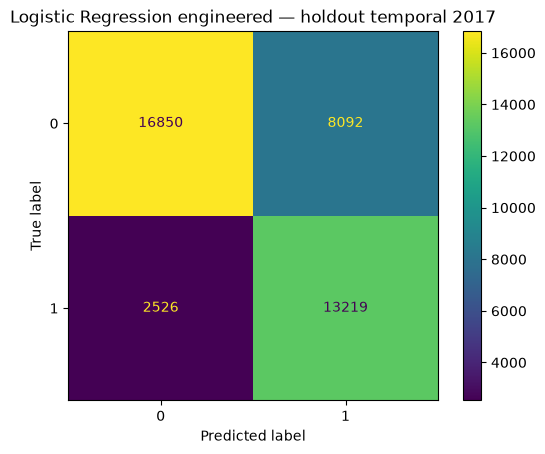

In [11]:
plot_confusion_matrix(
    best_logistic_model,
    X_validation,
    y_validation,
    threshold=0.5,
    title="Logistic Regression engineered — holdout temporal 2017",
)

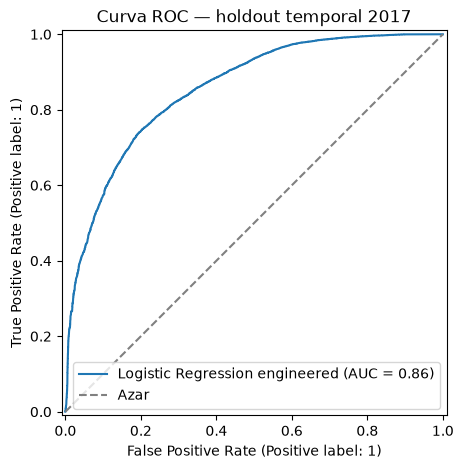

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(
    best_logistic_model,
    X_validation,
    y_validation,
    name="Logistic Regression engineered",
    ax=ax,
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — holdout temporal 2017")
ax.legend(loc="lower right")
plt.show()

## Coeficientes del modelo final

Los coeficientes positivos aumentan el log-odds de cancelación y los negativos lo reducen. Las variables numéricas fueron estandarizadas, por lo que sus magnitudes representan cambios de una desviación estándar. Las categorías se interpretan como contribuciones del pipeline regularizado y no como estimaciones causales.

In [13]:
fitted_preprocessor = best_logistic_model.named_steps["preprocessor"]
fitted_classifier = best_logistic_model.named_steps["model"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

coefficient_results = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient": fitted_classifier.coef_.ravel(),
})
coefficient_results["feature"] = coefficient_results["feature"].str.replace(
    r"^(numeric|categorical)__", "", regex=True
)
coefficient_results["odds_ratio"] = np.exp(coefficient_results["coefficient"])
coefficient_results["absolute_coefficient"] = coefficient_results["coefficient"].abs()

print("Mayores asociaciones positivas con la cancelación")
display(coefficient_results.nlargest(15, "coefficient").round(4))
print("Mayores asociaciones negativas con la cancelación")
display(coefficient_results.nsmallest(15, "coefficient").round(4))
print(f"Coeficientes exactamente nulos: {(coefficient_results['coefficient'] == 0).sum()}")

Mayores asociaciones positivas con la cancelación


,feature,coefficient,odds_ratio,absolute_coefficient
207,DistributionChannel_Undefined,4.4177,82.9095,4.4177
217,ReservedRoomType_P,4.1308,62.2264,4.1308
98,Country_HKG,2.6753,14.5171,2.6753
41,Country_ARE,2.5498,12.8042,2.5498
144,Country_NGA,2.4643,11.7555,2.4643
37,Country_AGO,2.4615,11.7220,2.4615
157,Country_PRT,2.1384,8.4855,2.1384
164,Country_SAU,1.9656,7.1391,1.9656
102,Country_IDN,1.9376,6.9419,1.9376
178,Country_TJK,1.7870,5.9712,1.7870


Mayores asociaciones negativas con la cancelación


,feature,coefficient,odds_ratio,absolute_coefficient
228,LeadTimeBand_Same day,-2.8809,0.0561,2.8809
9,RequiredCarParkingSpaces,-2.3864,0.0920,2.3864
222,LeadTimeBand_1-7 days,-2.1252,0.1194,2.1252
169,Country_SRB,-1.8792,0.1527,1.8792
126,Country_LTU,-1.5222,0.2182,1.5222
148,Country_NZL,-1.4742,0.2290,1.4742
66,Country_CMR,-1.2859,0.2764,1.2859
221,CustomerType_Transient-Party,-1.1621,0.3128,1.1621
142,Country_MYS,-1.1345,0.3216,1.1345
46,Country_AUT,-1.0406,0.3532,1.0406


Coeficientes exactamente nulos: 79


## Estabilidad de coeficientes entre folds

El mejor esquema se reajusta dentro de cada fold de desarrollo. Se resumen la magnitud media, la dispersión y la proporción de folds con coeficiente positivo. El holdout no participa en este análisis.

In [14]:
fold_coefficient_series = []
stability_cv = get_stratified_group_cross_validation(n_splits=5)

for fold, (fit_indices, validation_indices) in enumerate(
    stability_cv.split(X_train, y_train, groups=train_groups), start=1
):
    fold_model = clone(best_logistic_model)
    fold_model.fit(X_train.iloc[fit_indices], y_train.iloc[fit_indices])
    fold_preprocessor = fold_model.named_steps["preprocessor"]
    fold_classifier = fold_model.named_steps["model"]
    fold_names = pd.Index(fold_preprocessor.get_feature_names_out()).str.replace(
        r"^(numeric|categorical)__", "", regex=True
    )
    fold_coefficient_series.append(pd.Series(
        fold_classifier.coef_.ravel(), index=fold_names, name=f"fold_{fold}"
    ))

fold_coefficients = pd.concat(fold_coefficient_series, axis=1).fillna(0.0)
coefficient_stability = pd.DataFrame({
    "mean_coefficient": fold_coefficients.mean(axis=1),
    "std_coefficient": fold_coefficients.std(axis=1, ddof=0),
    "mean_absolute_coefficient": fold_coefficients.abs().mean(axis=1),
    "positive_fold_share": fold_coefficients.gt(0).mean(axis=1),
})
coefficient_stability["same_sign_all_folds"] = (
    coefficient_stability["positive_fold_share"].isin([0.0, 1.0])
)
coefficient_stability = coefficient_stability.sort_values(
    "mean_absolute_coefficient", ascending=False
)
display(coefficient_stability.head(30).round(4))

,mean_coefficient,std_coefficient,mean_absolute_coefficient,positive_fold_share,same_sign_all_folds
DistributionChannel_Undefined,3.9664,0.3095,3.9664,1.0,True
ReservedRoomType_P,3.8241,0.3144,3.8241,1.0,True
LeadTimeBand_Same day,-2.8465,0.0664,2.8465,0.0,True
Country_ARE,2.4731,0.1606,2.4731,1.0,True
Country_AGO,2.4381,0.2756,2.4381,1.0,True
Country_HKG,2.4146,0.1713,2.4146,1.0,True
RequiredCarParkingSpaces,-2.3432,0.0224,2.3432,0.0,True
Country_NGA,2.3368,0.2675,2.3368,1.0,True
Country_PRT,2.1281,0.0343,2.1281,1.0,True
LeadTimeBand_1-7 days,-2.0915,0.0482,2.0915,0.0,True


## Conclusiones pendientes de ejecución

Después de ejecutar el notebook se registrarán: la configuración elegida, la comparación CV/holdout frente al baseline, el posible gap temporal, las bandas de anticipación más relevantes y la estabilidad de los coeficientes.

La optimización del threshold y el análisis económico se posponen hasta disponer de los demás modelos, para aplicar una política operativa común.